In [1]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.preprocessing import LabelEncoder

import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import xgboost as xgb

# Load the Dataset

In [2]:
# Dataset Origin: https://www.kaggle.com/competitions/playground-series-s4e8

traincsvFile = pd.read_csv('Data/train.csv')
testcsvFile = pd.read_csv("Data/test.csv")

print("Data loaded")

Data loaded


# Inspect the Dataset

In [3]:
# Display basic information about the dataset
print(f"Dataset shape: {traincsvFile.shape}")
print(f"\nFirst five rows of the dataset:\n{traincsvFile.head()}")

Dataset shape: (3116945, 22)

First five rows of the dataset:
   id class  cap-diameter cap-shape cap-surface cap-color  \
0   0     e          8.80         f           s         u   
1   1     p          4.51         x           h         o   
2   2     e          6.94         f           s         b   
3   3     e          3.88         f           y         g   
4   4     e          5.85         x           l         w   

  does-bruise-or-bleed gill-attachment gill-spacing gill-color  ...  \
0                    f               a            c          w  ...   
1                    f               a            c          n  ...   
2                    f               x            c          w  ...   
3                    f               s          NaN          g  ...   
4                    f               d          NaN          w  ...   

   stem-root  stem-surface stem-color veil-type veil-color has-ring ring-type  \
0        NaN           NaN          w       NaN        NaN     

In [4]:
# Identify categorical columns
string_columns = traincsvFile.select_dtypes(include=['object']).columns
print(f"Categorical columns identified: {list(string_columns)}")

Categorical columns identified: ['class', 'cap-shape', 'cap-surface', 'cap-color', 'does-bruise-or-bleed', 'gill-attachment', 'gill-spacing', 'gill-color', 'stem-root', 'stem-surface', 'stem-color', 'veil-type', 'veil-color', 'has-ring', 'ring-type', 'spore-print-color', 'habitat', 'season']


# Encode Categorical Columns

In [5]:
# Map each unique string in categorical columns to an integer value
for column in string_columns:
    print(f"Encoding column: {column}")
    unique_strings = traincsvFile[column].unique()
    string_to_index = {string: index for index, string in enumerate(unique_strings)}
    traincsvFile[column] = traincsvFile[column].map(string_to_index)

print("\nCategorical columns successfully encoded.")

Encoding column: class
Encoding column: cap-shape
Encoding column: cap-surface
Encoding column: cap-color
Encoding column: does-bruise-or-bleed
Encoding column: gill-attachment
Encoding column: gill-spacing
Encoding column: gill-color
Encoding column: stem-root
Encoding column: stem-surface
Encoding column: stem-color
Encoding column: veil-type
Encoding column: veil-color
Encoding column: has-ring
Encoding column: ring-type
Encoding column: spore-print-color
Encoding column: habitat
Encoding column: season

Categorical columns successfully encoded.


# Split the Dataset

In [6]:
# Separate features (X) and target variable (Y)
print("Splitting dataset into features and target variable...")
X = traincsvFile.drop(columns=['id', 'class', 'stem-root', 'has-ring', 'cap-shape', 'stem-surface',
                               'habitat', 'ring-type', 'season', 'veil-color', 'veil-type', 'spore-print-color'])
Y = traincsvFile['class']

# Split data into training, validation, and test sets
print("Performing train-validation-test split...")
train_split = int(0.5 * len(Y))  # 50% training
val_split = int(0.75 * len(Y))   # 25% validation, 25% testing

# Training set
X_train = X[:train_split]
Y_train = Y[:train_split]

# Validation set
X_val = X[train_split:val_split]
Y_val = Y[train_split:val_split]

# Test set
X_test = X[val_split:]
Y_test = Y[val_split:]

# Confirm the split
print(f"\nTraining set Size: {X_train.shape}")
print(f"Validation set Size: {X_val.shape}")
print(f"Test set Size: {X_test.shape}")

Splitting dataset into features and target variable...
Performing train-validation-test split...

Training set Size: (1558472, 10)
Validation set Size: (779236, 10)
Test set Size: (779237, 10)


# Handle Missing Values

In [7]:
print("Checking for missing values...")
print(f"\nMissing values in X_train:\n{X_train.isnull().sum()}")
print(f"\nMissing values in X_test:\n{X_test.isnull().sum()}")

Checking for missing values...

Missing values in X_train:
cap-diameter            1
cap-surface             0
cap-color               0
does-bruise-or-bleed    0
gill-attachment         0
gill-spacing            0
gill-color              0
stem-height             0
stem-width              0
stem-color              0
dtype: int64

Missing values in X_test:
cap-diameter            1
cap-surface             0
cap-color               0
does-bruise-or-bleed    0
gill-attachment         0
gill-spacing            0
gill-color              0
stem-height             0
stem-width              0
stem-color              0
dtype: int64


In [8]:
print("Imputing missing values with column mean...")
imputer = SimpleImputer(strategy="mean")

# Impute training, validation, and test sets
X_train = imputer.fit_transform(X_train)
X_val = imputer.transform(X_val)
X_test = imputer.transform(X_test)

print("Missing values handled successfully.")

Imputing missing values with column mean...
Missing values handled successfully.


# Train XGBoost Model

In [9]:
# Prepare data for XGBoost
dtrain = xgb.DMatrix(X_train, label=Y_train)
dval = xgb.DMatrix(X_val, label=Y_val)
dtest = xgb.DMatrix(X_test, label=Y_test)

# Define XGBoost model
params = {
    'max_depth': 6,
    'eta': 0.1,
    'objective': 'binary:logistic',
    'eval_metric': 'auc'
}

# Train the XGBoost model
print("Training XGBoost model...")
bst = xgb.train(
    params=params,
    dtrain=dtrain,
    num_boost_round=100,
    evals=[(dtrain, 'train'), (dval, 'validation')],
    early_stopping_rounds=10,
    verbose_eval=True
)

print("\nXGBoost model training complete.")

Training XGBoost model...
[0]	train-auc:0.89172	validation-auc:0.89131
[1]	train-auc:0.89731	validation-auc:0.89680
[2]	train-auc:0.91689	validation-auc:0.91633
[3]	train-auc:0.93824	validation-auc:0.93784
[4]	train-auc:0.94323	validation-auc:0.94288
[5]	train-auc:0.94522	validation-auc:0.94488
[6]	train-auc:0.95781	validation-auc:0.95754
[7]	train-auc:0.96364	validation-auc:0.96341
[8]	train-auc:0.96881	validation-auc:0.96863
[9]	train-auc:0.97238	validation-auc:0.97225
[10]	train-auc:0.97328	validation-auc:0.97316
[11]	train-auc:0.97560	validation-auc:0.97549
[12]	train-auc:0.97708	validation-auc:0.97694
[13]	train-auc:0.97867	validation-auc:0.97854
[14]	train-auc:0.97980	validation-auc:0.97962
[15]	train-auc:0.98124	validation-auc:0.98107
[16]	train-auc:0.98252	validation-auc:0.98233
[17]	train-auc:0.98292	validation-auc:0.98271
[18]	train-auc:0.98390	validation-auc:0.98369
[19]	train-auc:0.98461	validation-auc:0.98440
[20]	train-auc:0.98539	validation-auc:0.98516
[21]	train-auc:0.9

# Evaluate XGBoost Model

In [10]:
print("Generating predictions for XGBoost model...")
y_pred_prob_xgb = bst.predict(dtest)  # Predicted probabilities
y_pred_xgb = (y_pred_prob_xgb > 0.5).astype(int)  # Convert probabilities to binary predictions

# Calculate Accuracy and ROC-AUC
accuracy_xgb = accuracy_score(Y_test, y_pred_xgb)
roc_auc_xgb = roc_auc_score(Y_test, y_pred_prob_xgb)

# Generate classification report
print("Evaluating XGBoost model performance...")
report_xgb = classification_report(Y_test, y_pred_xgb, target_names=["Class 0", "Class 1"])

# Print results
print("\nXGBoost Model Performance:")
print(f"Accuracy: {accuracy_xgb:.4f}")
print(f"ROC-AUC: {roc_auc_xgb:.4f}")
print("\nClassification Report:")
print(report_xgb)

Generating predictions for XGBoost model...
Evaluating XGBoost model performance...

XGBoost Model Performance:
Accuracy: 0.9812
ROC-AUC: 0.9946

Classification Report:
              precision    recall  f1-score   support

     Class 0       0.98      0.98      0.98    352584
     Class 1       0.98      0.98      0.98    426653

    accuracy                           0.98    779237
   macro avg       0.98      0.98      0.98    779237
weighted avg       0.98      0.98      0.98    779237



# XGBoost Feature Importance

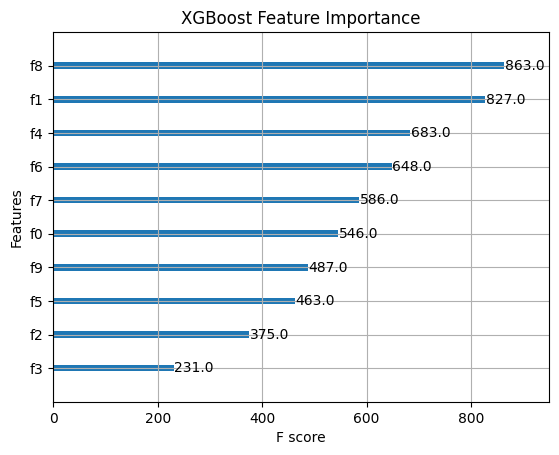

In [11]:
# Plot the top 10 most important features
xgb.plot_importance(bst, importance_type='weight', max_num_features=10)
plt.title("XGBoost Feature Importance")
plt.show()

# Train Logistic Regression Model

In [12]:
print("Training Logistic Regression model...")
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, Y_train)

# Confirm training completion
print("\nLogistic Regression model training complete.")

Training Logistic Regression model...

Logistic Regression model training complete.


# Evaluate Logistic Regression Model

In [13]:
print("Generating predictions for Logistic Regression model...")
y_pred_prob_lr = lr.predict_proba(X_test)[:, 1]  # Predicted probabilities
y_pred_lr = (y_pred_prob_lr > 0.5).astype(int)  # Convert probabilities to binary predictions

# Calculate Accuracy and ROC-AUC
accuracy_lr = accuracy_score(Y_test, y_pred_lr)
roc_auc_lr = roc_auc_score(Y_test, y_pred_prob_lr)

# Generate classification report
print("Evaluating Logistic Regression model performance...")
report_lr = classification_report(Y_test, y_pred_lr, target_names=["Class 0", "Class 1"])

# Print results
print("\nLogistic Regression Model Performance:")
print(f"Accuracy: {accuracy_lr:.4f}")
print(f"ROC-AUC: {roc_auc_lr:.4f}")
print("\nClassification Report:")
print(report_lr)

Generating predictions for Logistic Regression model...
Evaluating Logistic Regression model performance...

Logistic Regression Model Performance:
Accuracy: 0.6303
ROC-AUC: 0.6831

Classification Report:
              precision    recall  f1-score   support

     Class 0       0.61      0.52      0.56    352584
     Class 1       0.65      0.72      0.68    426653

    accuracy                           0.63    779237
   macro avg       0.63      0.62      0.62    779237
weighted avg       0.63      0.63      0.63    779237



# Train Random Forest Model

In [14]:
print("Training Random Forest model...")
print("This will take about 5.5 minutes.")
rf = RandomForestClassifier(n_estimators=100)  # Set the number of trees
rf.fit(X_train, Y_train)

print("\nRandom Forest model training complete.")

Training Random Forest model...
This will take about 5.5 minutes.

Random Forest model training complete.


# Cross-Validation for Random Forest Model

In [15]:
print("Performing 5-fold cross-validation on Random Forest model...")
print("This will take about 20 minutes.")

# Perform cross-validation
cv_scores = cross_val_score(rf, X_train, Y_train, cv=5, scoring="accuracy")

# Display cross-validation results
print("\nCross-validation complete.")
print(f"\nCross-Validation Accuracy Scores: {cv_scores}")
print(f"Mean CV Accuracy: {cv_scores.mean():.4f}")

Performing 5-fold cross-validation on Random Forest model...
This will take about 20 minutes.

Cross-validation complete.

Cross-Validation Accuracy Scores: [0.99015704 0.9897111  0.98980731 0.98975919 0.98990356]
Mean CV Accuracy: 0.9899


# Evaluate Random Forest Model

In [16]:
print("Generating predictions for Random Forest model...")
y_pred_prob_rf = rf.predict_proba(X_test)[:, 1]  # Predicted probabilities
y_pred_rf = (y_pred_prob_rf > 0.5).astype(int)  # Convert probabilities to binary predictions

# Calculate Accuracy and ROC-AUC
accuracy_rf = accuracy_score(Y_test, y_pred_rf)
roc_auc_rf = roc_auc_score(Y_test, y_pred_prob_rf)

# Generate classification report
print("Evaluating Random Forest model performance...")
report_rf = classification_report(Y_test, y_pred_rf, target_names=["Class 0", "Class 1"])

# Print results
print("\nRandom Forest Model Performance:")
print(f"Accuracy: {accuracy_rf:.4f}")
print(f"ROC-AUC: {roc_auc_rf:.4f}")
print("\nClassification Report:")
print(report_rf)

Generating predictions for Random Forest model...
Evaluating Random Forest model performance...

Random Forest Model Performance:
Accuracy: 0.9901
ROC-AUC: 0.9956

Classification Report:
              precision    recall  f1-score   support

     Class 0       0.99      0.99      0.99    352584
     Class 1       0.99      0.99      0.99    426653

    accuracy                           0.99    779237
   macro avg       0.99      0.99      0.99    779237
weighted avg       0.99      0.99      0.99    779237



# Random Forest Feature Importance

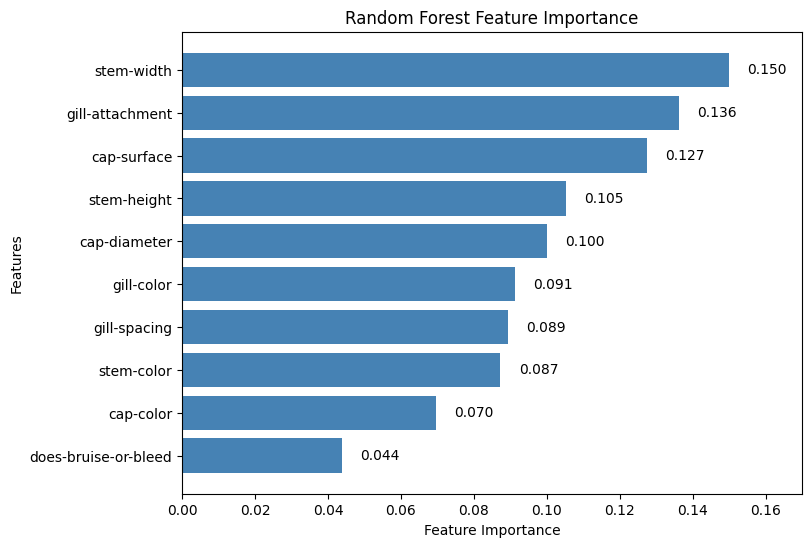

In [17]:
# Reassign column names to X_train after imputation
X_train_df = pd.DataFrame(X_train, columns=X.columns)

# Extract feature importance from the model
importances = rf.feature_importances_

# Create a DataFrame for feature importance
rf_importance_df = pd.DataFrame({
    "Feature": X_train_df.columns,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

# Plot the top 10 features
top_features = rf_importance_df.head(10)
plt.figure(figsize=(8, 6))
bars = plt.barh(top_features["Feature"], top_features["Importance"], color="steelblue")

# Adjust x-axis limit to fit annotations
plt.xlim(0, top_features["Importance"].max() + 0.02)  # Add padding to the max value

# Add labels and title
plt.xlabel("Feature Importance")
plt.ylabel("Features")
plt.title("Random Forest Feature Importance")
plt.gca().invert_yaxis()  # Reverse the order of features to match the XGBoost plot

# Add annotations (feature importance values)
for bar, value in zip(bars, top_features["Importance"]):
    plt.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2, f'{value:.3f}', va='center')

plt.show()

# Model Performance Comparison

In [18]:
# Extract metrics from classification reports
def extract_metrics(report):
    lines = report.split('\n')
    for line in lines:
        if 'weighted avg' in line:
            avg_metrics = line.split()
            return float(avg_metrics[2]), float(avg_metrics[3]), float(avg_metrics[4])  # Precision, Recall, F1 Score

# Extract additional metrics for each model
precision_xgb, recall_xgb, f1_xgb = extract_metrics(report_xgb)
precision_lr, recall_lr, f1_lr = extract_metrics(report_lr)
precision_rf, recall_rf, f1_rf = extract_metrics(report_rf)

# Create a dictionary with the results
results_dict = {
    "Model": ["XGBoost", "Logistic Regression", "Random Forest"],
    "Accuracy": [accuracy_xgb, accuracy_lr, accuracy_rf],
    "Precision": [precision_xgb, precision_lr, precision_rf],
    "Recall": [recall_xgb, recall_lr, recall_rf],
    "F1 Score": [f1_xgb, f1_lr, f1_rf],
    "ROC-AUC": [roc_auc_xgb, roc_auc_lr, roc_auc_rf]
}

# Convert to a DataFrame
results_df = pd.DataFrame(results_dict)

# Display the results table
print("\nModel Performance Comparison:")
print(results_df)

# Save results to a CSV file for future use
results_df.to_csv("Results/models_against_train_comparison.csv", index=False)
print("\nTrain Results Comparison saved as 'models_against_train_comparison.csv'.")


Model Performance Comparison:
                 Model  Accuracy  Precision  Recall  F1 Score   ROC-AUC
0              XGBoost  0.981167       0.98    0.98      0.98  0.994639
1  Logistic Regression  0.630299       0.63    0.63      0.63  0.683139
2        Random Forest  0.990122       0.99    0.99      0.99  0.995617

Train Results Comparison saved as 'models_against_train_comparison.csv'.


# Test XGBoost Model on the Test Data

In [19]:
print("Evaluating XGBoost model on test data...")
y_test_pred_prob_xgb = bst.predict(dtest)  # Predicted probabilities
y_test_pred_xgb = (y_test_pred_prob_xgb > 0.5).astype(int)  # Convert probabilities to binary predictions

# Calculate metrics
xgb_test_accuracy = accuracy_score(Y_test, y_test_pred_xgb)
xgb_test_roc_auc = roc_auc_score(Y_test, y_test_pred_prob_xgb)
xgb_test_report = classification_report(Y_test, y_test_pred_xgb, target_names=["Class 0", "Class 1"])

# Display results
print("\nXGBoost Test Performance:")
print(f"Accuracy: {xgb_test_accuracy:.4f}")
print(f"ROC-AUC: {xgb_test_roc_auc:.4f}")
print("\nClassification Report:")
print(xgb_test_report)

Evaluating XGBoost model on test data...

XGBoost Test Performance:
Accuracy: 0.9812
ROC-AUC: 0.9946

Classification Report:
              precision    recall  f1-score   support

     Class 0       0.98      0.98      0.98    352584
     Class 1       0.98      0.98      0.98    426653

    accuracy                           0.98    779237
   macro avg       0.98      0.98      0.98    779237
weighted avg       0.98      0.98      0.98    779237



# Test Logistic Regression Model on the Test Data

In [20]:
print("Evaluating Logistic Regression model on test data...")
y_test_pred_prob_lr = lr.predict_proba(X_test)[:, 1]  # Predicted probabilities
y_test_pred_lr = (y_test_pred_prob_lr > 0.5).astype(int)  # Convert probabilities to binary predictions

# Calculate metrics
lr_test_accuracy = accuracy_score(Y_test, y_test_pred_lr)
lr_test_roc_auc = roc_auc_score(Y_test, y_test_pred_prob_lr)
lr_test_report = classification_report(Y_test, y_test_pred_lr, target_names=["Class 0", "Class 1"])

# Display results
print("\nLogistic Regression Test Performance:")
print(f"Accuracy: {lr_test_accuracy:.4f}")
print(f"ROC-AUC: {lr_test_roc_auc:.4f}")
print("\nClassification Report:")
print(lr_test_report)

Evaluating Logistic Regression model on test data...

Logistic Regression Test Performance:
Accuracy: 0.6303
ROC-AUC: 0.6831

Classification Report:
              precision    recall  f1-score   support

     Class 0       0.61      0.52      0.56    352584
     Class 1       0.65      0.72      0.68    426653

    accuracy                           0.63    779237
   macro avg       0.63      0.62      0.62    779237
weighted avg       0.63      0.63      0.63    779237



# Test Random Forest Model on the Test Data

In [21]:
print("Evaluating Random Forest model on test data...")
y_test_pred_prob_rf = rf.predict_proba(X_test)[:, 1]  # Predicted probabilities
y_test_pred_rf = (y_test_pred_prob_rf > 0.5).astype(int)  # Convert probabilities to binary predictions

# Calculate metrics
rf_test_accuracy = accuracy_score(Y_test, y_test_pred_rf)
rf_test_roc_auc = roc_auc_score(Y_test, y_test_pred_prob_rf)
rf_test_report = classification_report(Y_test, y_test_pred_rf, target_names=["Class 0", "Class 1"])

# Display results
print("\nRandom Forest Test Performance:")
print(f"Accuracy: {rf_test_accuracy:.4f}")
print(f"ROC-AUC: {rf_test_roc_auc:.4f}")
print("\nClassification Report:")
print(rf_test_report)

Evaluating Random Forest model on test data...

Random Forest Test Performance:
Accuracy: 0.9901
ROC-AUC: 0.9956

Classification Report:
              precision    recall  f1-score   support

     Class 0       0.99      0.99      0.99    352584
     Class 1       0.99      0.99      0.99    426653

    accuracy                           0.99    779237
   macro avg       0.99      0.99      0.99    779237
weighted avg       0.99      0.99      0.99    779237



# Compare Test Data Results

In [22]:
# Extract Metrics from Classification Reports
def extract_test_metrics(report):
    lines = report.split('\n')
    for line in lines:
        if 'weighted avg' in line:  # Look for the 'weighted avg' line
            metrics = line.split()
            return float(metrics[2]), float(metrics[3]), float(metrics[4]), int(metrics[5])  # Precision, Recall, F1-Score, Support

# Extract metrics for each model
precision_xgb, recall_xgb, f1_xgb, support_xgb = extract_test_metrics(xgb_test_report)
precision_lr, recall_lr, f1_lr, support_lr = extract_test_metrics(lr_test_report)
precision_rf, recall_rf, f1_rf, support_rf = extract_test_metrics(rf_test_report)

# Create a comprehensive dictionary with all metrics
test_results_dict = {
    "Model": ["XGBoost", "Logistic Regression", "Random Forest"],
    "Accuracy": [xgb_test_accuracy, lr_test_accuracy, rf_test_accuracy],
    "Precision": [precision_xgb, precision_lr, precision_rf],
    "Recall": [recall_xgb, recall_lr, recall_rf],
    "F1 Score": [f1_xgb, f1_lr, f1_rf],
    "ROC-AUC": [xgb_test_roc_auc, lr_test_roc_auc, rf_test_roc_auc]
}

# Convert to a DataFrame
test_results_df = pd.DataFrame(test_results_dict)

# Display the results table
print("Test Results Comparison with Detailed Metrics:")
print(test_results_df)

# Save to CSV
test_results_df.to_csv("Results/models_against_test_comparison.csv", index=False)
print("\nTest Results Comparison saved as 'models_against_test_comparison.csv'.")

Test Results Comparison with Detailed Metrics:
                 Model  Accuracy  Precision  Recall  F1 Score   ROC-AUC
0              XGBoost  0.981167       0.98    0.98      0.98  0.994639
1  Logistic Regression  0.630299       0.63    0.63      0.63  0.683139
2        Random Forest  0.990122       0.99    0.99      0.99  0.995617

Test Results Comparison saved as 'models_against_test_comparison.csv'.


# Save Winning Model Predictions (Random Forest)

In [23]:
# Ensure the test dataset aligns with the predictions
aligned_test_ids = testcsvFile["id"][:len(y_test_pred_rf)]  # Align the ID column with the length of predictions

# Create a DataFrame to store the predictions
rf_predictions_df = pd.DataFrame({
    "id": aligned_test_ids,
    "Predicted_Class": y_test_pred_rf
})

# Save to CSV
rf_predictions_df.to_csv("Results/random_forest_test_predictions.csv", index=False)
print("Predictions saved to 'random_forest_test_predictions.csv'.")

Predictions saved to 'random_forest_test_predictions.csv'.


# Confusion Matrix for Winning Model (Random Forest)

Random Forest Confusion Matrix:
[[349033   3551]
 [  4146 422507]]


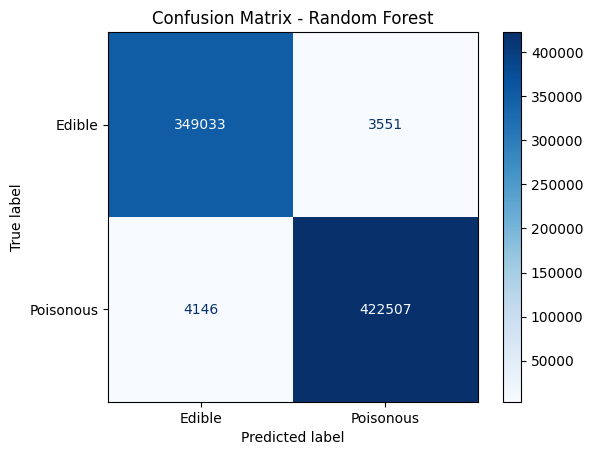

In [25]:
# Compute confusion matrix for Random Forest
rf_cm = confusion_matrix(Y_test, y_test_pred_rf)

# Display confusion matrix
print("Random Forest Confusion Matrix:")
print(rf_cm)

# Visualize confusion matrix
class_labels = ["Edible", "Poisonous"]
disp = ConfusionMatrixDisplay(confusion_matrix=rf_cm, display_labels=class_labels)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Random Forest")
plt.show()